In [1]:
import os
import math
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from sklearn.metrics import mean_absolute_error, mean_squared_error

from arch import arch_model

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True


## 1. Chargement et preparation des donnees

On transforme les donnees de contrats en serie mensuelle. Dans ce lab, la date d'observation prioritaire est `Date_last_renewal`, car elle correspond a la periode de renouvellement/observation du contrat.

La serie principale analysee est le **cout total mensuel des sinistres** (`cout_total`). On calcule aussi :

- `nb_sinistres` : nombre total de sinistres observes par mois ;
- `nb_contrats` : nombre de contrats observes par mois ;
- `frequence` : sinistres / contrats ;
- `severite` : cout total / nombre de sinistres ;
- `prime_pure` : cout total / nombre de contrats.

In [2]:
FILE_PATH = '/content/Motor vehicle insurance data.csv'

df = pd.read_csv(FILE_PATH, sep=';')
print(f"📊 Dimensions du fichier : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.head(3)

📊 Dimensions du fichier : 105,555 lignes x 30 colonnes


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


In [3]:
# Conversion des dates
for col in ["Date_last_renewal", "Date_start_contract", "Date_next_renewal", "Date_birth", "Date_driving_licence"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Date d'observation
DATE_COL = "Date_last_renewal" if "Date_last_renewal" in df.columns else "Date_start_contract"
df = df.dropna(subset=[DATE_COL]).copy()

# Colonnes numeriques utiles
for col in ["N_claims_year", "Cost_claims_year", "Premium"]:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

monthly = (
    df.set_index(DATE_COL)
      .resample("ME")
      .agg(
          nb_sinistres=("N_claims_year", "sum"),
          cout_total=("Cost_claims_year", "sum"),
          prime_total=("Premium", "sum"),
          nb_contrats=("ID", "count") if "ID" in df.columns else ("Premium", "count"),
      )
)

monthly["frequence"] = monthly["nb_sinistres"] / monthly["nb_contrats"].replace(0, np.nan)
monthly["severite"] = monthly["cout_total"] / monthly["nb_sinistres"].replace(0, np.nan)
monthly["prime_pure"] = monthly["cout_total"] / monthly["nb_contrats"].replace(0, np.nan)
monthly = monthly.fillna(0)

print(monthly.shape)
monthly.head()

(37, 7)


,nb_sinistres,cout_total,prime_total,nb_contrats,frequence,severite,prime_pure
Date_last_renewal,,,,,,,
2015-11-30,1377,523571.19,651354.14,2091,0.658537,380.225991,250.392726
2015-12-31,1863,669393.68,788242.08,2468,0.754862,359.309544,271.229206
2016-01-31,1780,605402.44,745900.67,2338,0.761334,340.113730,258.940308
2016-02-29,1638,642212.80,759686.44,2394,0.684211,392.071306,268.259315
2016-03-31,1991,726989.63,848657.55,2658,0.749059,365.137936,273.510019


## 2. Visualisation initiale et interpretation

On commence par visualiser la serie principale. Cette etape sert a detecter visuellement :

- une **tendance** : hausse ou baisse structurelle ;
- une **saisonnalite** : motifs repetitifs ;
- des **ruptures** ou valeurs atypiques ;
- une volatilite croissante ou decroissante.

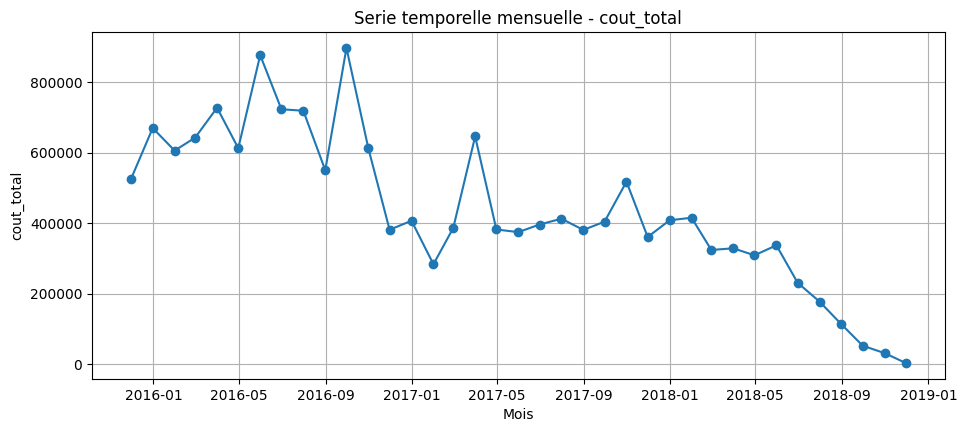

Periode : 2015-11-30 -> 2018-11-30
Nombre de periodes : 37


In [4]:
TARGET = "cout_total"   # Essayez aussi : nb_sinistres, frequence, severite, prime_pure

ts = monthly[TARGET].asfreq("ME")

plt.figure()
plt.plot(ts.index, ts.values, marker="o")
plt.title(f"Serie temporelle mensuelle - {TARGET}")
plt.xlabel("Mois")
plt.ylabel(TARGET)
plt.show()

print("Periode :", ts.index.min().date(), "->", ts.index.max().date())
print("Nombre de periodes :", len(ts))

### Interpretation attendue

Dans ce portefeuille, on observe generalement une evolution mensuelle non constante. Une serie dont le niveau moyen change dans le temps est souvent **non stationnaire**, ce qui justifie l'utilisation d'une differenciation dans les modeles ARIMA/SARIMA.

## 3. Decomposition : tendance, saisonnalite, residu

On applique une decomposition additive :

\[
Y_t = T_t + S_t + R_t
\]

ou :

- \(T_t\) est la tendance ;
- \(S_t\) est la saisonnalite ;
- \(R_t\) est le residu non explique.

La periode saisonniere est fixee a 12 pour une saisonnalite annuelle sur donnees mensuelles.

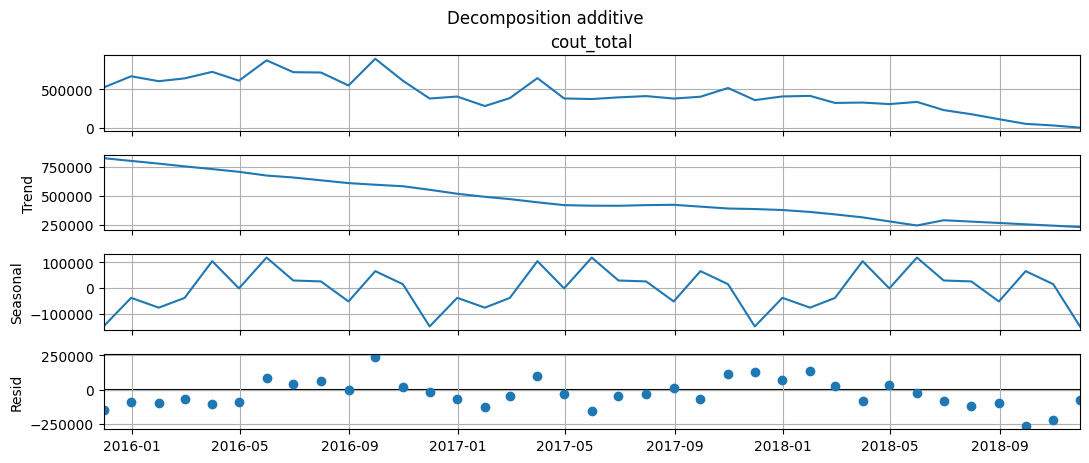

In [5]:
if len(ts.dropna()) >= 24:
    decomp = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")
    decomp.plot()
    plt.suptitle("Decomposition additive", y=1.02)
    plt.show()
else:
    print("Pas assez d'observations pour une decomposition saisonniere fiable.")

### Interpretation

- Si la composante tendance varie fortement, la serie n'est probablement pas stationnaire.
- Si la composante saisonniere montre un motif repetitif tous les 12 mois, un modele SARIMA est plus adapte qu'un ARIMA simple.
- Si les residus conservent une structure visible, le modele devra etre ameliore.

## 4. Test de stationnarite ADF

Le test ADF teste :

- \(H_0\) : la serie possede une racine unitaire, donc elle est non stationnaire ;
- \(H_1\) : la serie est stationnaire.

Regle pratique :

- p-value < 0.05 : on rejette \(H_0\), la serie est stationnaire ;
- p-value >= 0.05 : on ne rejette pas \(H_0\), differenciation necessaire.

In [6]:
def adf_report(series, name):
    series = series.dropna()
    stat, pval, lags, nobs, crit, icbest = adfuller(series, autolag="AIC")
    print(f"ADF - {name}")
    print("Statistic:", round(stat, 4))
    print("p-value  :", round(pval, 4))
    print("lags     :", lags)
    print("nobs     :", nobs)
    print("Conclusion:", "stationnaire" if pval < 0.05 else "non stationnaire")
    return pval

p_original = adf_report(ts, "serie originale")

ADF - serie originale
Statistic: -1.4004
p-value  : 0.5821
lags     : 0
nobs     : 36
Conclusion: non stationnaire


## 5. Stationnarisation de la série

Le test ADF sur la série originale conclut à la **non-stationnarité** (p-value ≥ 0.05).  
Deux méthodes classiques permettent de la rendre stationnaire. On les applique toutes les deux, on vérifie chacune par ADF, puis on choisit la meilleure pour la suite.

| Méthode | Transformation | Idéale quand… |
|---------|----------------|--------------|
| **Différenciation (d = 1)** | $\Delta Y_t = Y_t - Y_{t-1}$ | La série a une tendance déterministe stable |
| **Log + différenciation** | $\Delta \ln Y_t = \ln Y_t - \ln Y_{t-1}$ | La variance croît avec le niveau (hétéroscédasticité multiplicative) |

Après avoir rendu la série stationnaire en *moyenne*, on ajuste un modèle **GARCH(1,1)** pour modéliser la **variance conditionnelle** résiduelle — ce que ni la différenciation ni le log ne capturent.


### 5a. Méthode 1 — Différenciation (d = 1)

In [ ]:
# ── Différenciation d=1 ─────────────────────────────────────────────────────
ts_diff = ts.diff().dropna()

plt.figure(figsize=(11, 4))
plt.plot(ts_diff.index, ts_diff.values, marker='o', markersize=4, color='steelblue')
plt.axhline(0, linestyle='--', color='red', linewidth=1)
plt.title(f'Méthode 1 — Série différenciée (d=1) : {TARGET}', fontweight='bold')
plt.xlabel('Mois'); plt.ylabel(f'Δ {TARGET}')
plt.tight_layout(); plt.show()

p_diff = adf_report(ts_diff, 'différenciée d=1')


### 5b. Méthode 2 — Transformation logarithmique puis différenciation

$$\Delta \ln Y_t = \ln Y_t - \ln Y_{t-1} \approx \frac{Y_t - Y_{t-1}}{Y_{t-1}} \quad \text{(taux de croissance mensuel)}$$

Cette transformation **comprime les grandes valeurs**, stabilise la variance, et produit une série interprétable comme taux de variation.


In [ ]:
# ── Log + différenciation ────────────────────────────────────────────────────
ts_pos = ts.copy()
if (ts_pos <= 0).any():
    shift = abs(ts_pos.min()) + 1
    ts_pos += shift
    print(f"⚠️  Décalage appliqué : +{shift:.2f} (nécessaire pour log)")

ts_log      = np.log(ts_pos)           # log seul — pour visualisation
ts_log_diff = ts_log.diff().dropna()   # log-différenciée — série stationnaire candidate

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ts_log.index, ts_log.values, marker='o', markersize=4, color='darkorange')
axes[0].set_title(f'log({TARGET})', fontweight='bold')
axes[0].set_ylabel(f'ln({TARGET})')

axes[1].plot(ts_log_diff.index, ts_log_diff.values, marker='o', markersize=4, color='darkgreen')
axes[1].axhline(0, linestyle='--', color='red', linewidth=1)
axes[1].set_title(f'Méthode 2 — Δln({TARGET})', fontweight='bold')
axes[1].set_ylabel(f'Δln({TARGET})')

plt.suptitle('Transformation logarithmique', fontweight='bold')
plt.tight_layout(); plt.show()

p_log      = adf_report(ts_log,      'log seul (non différencié)')
p_log_diff = adf_report(ts_log_diff, 'log-différenciée')


### 5c. Comparaison des deux méthodes — Test ADF

On compare les p-values ADF des deux séries transformées.  
La méthode retenue est celle dont la série est **stationnaire (p < 0.05)** avec la p-value la plus basse.  
Elle sera utilisée comme entrée pour ACF/PACF, ARIMA et SARIMA.


In [ ]:
# ── Bilan ADF ────────────────────────────────────────────────────────────────
print("=" * 65)
print("  COMPARAISON — Test ADF (H0 : non stationnaire)")
print("=" * 65)

adf_comparison = [
    ("Originale",          p_original),
    ("Différenciée d=1",   p_diff),
    ("Log-différenciée",   p_log_diff),
]
for label, pv in adf_comparison:
    icon = "✅" if pv < 0.05 else "❌"
    status = "STATIONNAIRE" if pv < 0.05 else "non stationnaire"
    print(f"  {icon}  {label:<25}  p = {pv:.4f}   {status}")
print("=" * 65)

# ── Graphique comparatif des p-values ────────────────────────────────────────
labels = [r[0] for r in adf_comparison]
pvals  = [r[1] for r in adf_comparison]
colors = ['green' if p < 0.05 else 'tomato' for p in pvals]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, pvals, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='Seuil 5 %')
ax.set_ylabel('p-value ADF')
ax.set_ylim(0, max(pvals) * 1.2)
ax.set_title('Test ADF — p-values par méthode de stationnarisation', fontweight='bold')
ax.legend()
for bar, pv in zip(bars, pvals):
    ax.text(bar.get_x() + bar.get_width()/2, pv + max(pvals)*0.03,
            f'{pv:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Choix automatique de la série stationnaire pour la suite ─────────────────
candidates = [(l, p, s) for (l, p), s in zip(
    [("Différenciée d=1", p_diff), ("Log-différenciée", p_log_diff)],
    [ts_diff, ts_log_diff]
) if p < 0.05]

if candidates:
    best_method, best_p, ts_stationary = min(candidates, key=lambda x: x[1])
else:
    # fallback : prendre diff même si p > 0.05
    best_method, best_p, ts_stationary = "Différenciée d=1 (fallback)", p_diff, ts_diff

print(f"\n📌 Méthode retenue pour ACF/PACF et ARIMA : {best_method}  (p = {best_p:.4f})")
print(f"   → Variable : ts_stationary  ({len(ts_stationary)} observations)")


### 5d. Modélisation GARCH — variance conditionnelle

Différenciation et log-diff rendent la série stationnaire **en moyenne**, mais la **variance** peut encore varier dans le temps (clusters de volatilité).  
Un modèle **GARCH(1,1)** est ajusté sur chaque série stationnaire pour modéliser $\sigma_t^2$ :

$$\sigma_t^2 = \omega + \alpha_1\,\varepsilon_{t-1}^2 + \beta_1\,\sigma_{t-1}^2$$

- $\alpha_1$ : réaction aux chocs passés  
- $\beta_1$ : persistance de la volatilité  
- $\alpha_1 + \beta_1 \approx 1$ → volatilité très persistante (typique en sinistralité assurance)

Les **résidus standardisés** $z_t = \varepsilon_t / \sigma_t$ doivent être un bruit blanc.


In [ ]:
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

# ── Test ARCH de Engle sur la série retenue ───────────────────────────────────
n_lags = min(5, len(ts_stationary) // 4)
lm_stat, lm_pval, _, _ = het_arch(ts_stationary.replace([np.inf,-np.inf], np.nan).dropna(),
                                   nlags=n_lags)
print(f"🔍 Test ARCH de Engle sur '{best_method}' (lags={n_lags})")
print(f"   stat = {lm_stat:.4f}   p = {lm_pval:.4f}")
print("  →", "✅ Hétéroscédasticité conditionnelle détectée"
      if lm_pval < 0.05 else "ℹ️  Pas d'hétéroscédasticité forte — GARCH modélisera quand même la volatilité résiduelle")

# ── Mise à l'échelle pour stabilité numérique si log-diff ────────────────────
_scale = 100 if "log" in best_method.lower() else 1
ts_garch_input = (ts_stationary * _scale).replace([np.inf,-np.inf], np.nan).dropna()

# ── GARCH(1,1) sur la série différenciée ─────────────────────────────────────
garch_diff_input = (ts_diff * (100 if False else 1)).replace([np.inf,-np.inf], np.nan).dropna()
res_garch_diff = arch_model(garch_diff_input, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
print("\n── GARCH(1,1)-t sur série DIFFÉRENCIÉE ──")
print(res_garch_diff.summary())

# ── GARCH(1,1) sur la série log-différenciée ──────────────────────────────────
garch_logdiff_input = (ts_log_diff * 100).replace([np.inf,-np.inf], np.nan).dropna()
res_garch_log  = arch_model(garch_logdiff_input, vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
print("\n── GARCH(1,1)-t sur série LOG-DIFFÉRENCIÉE ──")
print(res_garch_log.summary())


In [ ]:
# ── Visualisation : 4 séries côte à côte ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 0 : les deux séries stationnaires
axes[0,0].plot(ts_diff.index, ts_diff.values, color='steelblue', marker='o', markersize=3)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title(f'Différenciée d=1  (ADF p={p_diff:.4f})', fontweight='bold')
axes[0,0].set_ylabel(f'Δ {TARGET}')

axes[0,1].plot(ts_log_diff.index, ts_log_diff.values, color='darkgreen', marker='o', markersize=3)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title(f'Log-différenciée  (ADF p={p_log_diff:.4f})', fontweight='bold')
axes[0,1].set_ylabel(f'Δln({TARGET})')

# Row 1 : volatilité conditionnelle GARCH pour chaque
v1 = res_garch_diff.conditional_volatility
axes[1,0].fill_between(v1.index, v1.values, alpha=0.4, color='steelblue')
axes[1,0].plot(v1.index, v1.values, color='steelblue', linewidth=1.5)
axes[1,0].set_title(f'GARCH(1,1) — Volatilité conditionnelle σ_t\n(diff d=1)  AIC={res_garch_diff.aic:.1f}',
                    fontweight='bold')
axes[1,0].set_ylabel('σ_t')

v2 = res_garch_log.conditional_volatility
axes[1,1].fill_between(v2.index, v2.values, alpha=0.4, color='darkgreen')
axes[1,1].plot(v2.index, v2.values, color='darkgreen', linewidth=1.5)
axes[1,1].set_title(f'GARCH(1,1) — Volatilité conditionnelle σ_t\n(log-diff)  AIC={res_garch_log.aic:.1f}',
                    fontweight='bold')
axes[1,1].set_ylabel('σ_t')

plt.suptitle('Comparaison complète : Différenciation vs Log-diff + GARCH(1,1)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 5e. Bilan et choix final

On compare les deux méthodes sur **trois critères** :

| Critère | Différenciée d=1 | Log-différenciée |
|---------|-----------------|-----------------|
| **Stationnarité (ADF p-value)** | voir ci-dessus | voir ci-dessus |
| **Interprétation** | Variation absolue (€) | Taux de croissance (%) |
| **GARCH AIC** | voir ci-dessus | voir ci-dessus |

La série retenue (`ts_stationary`) est utilisée pour la suite : **ACF/PACF → ARIMA → SARIMA → prévision**.


In [ ]:
# ── Tableau de bilan final ───────────────────────────────────────────────────
print("=" * 70)
print("  BILAN FINAL — STATIONNARISATION")
print("=" * 70)
print(f"  {'Méthode':<28} {'ADF p-value':>12}  {'Stationnaire':>13}  {'GARCH AIC':>10}")
print("  " + "─"*64)
bilan = [
    ("Originale",          p_original, "—",           "—"),
    ("Différenciée d=1",   p_diff,     "diff",         f"{res_garch_diff.aic:.1f}"),
    ("Log-différenciée",   p_log_diff, "log_diff",     f"{res_garch_log.aic:.1f}"),
]
for label, pv, key, aic_str in bilan:
    icon = "✅" if pv < 0.05 else "❌"
    star = "  ◀ RETENUE" if label == best_method else ""
    print(f"  {icon}  {label:<26} {pv:>12.4f}  {'OUI' if pv < 0.05 else 'NON':>13}  {aic_str:>10}{star}")
print("=" * 70)

print(f"\n📌 Série retenue pour la modélisation : '{best_method}'")
print(f"   → ts_stationary utilisée pour ACF/PACF, ARIMA et SARIMA")
print(f"\n💡 Le modèle GARCH(1,1) sur cette série capture la volatilité résiduelle.")
print(f"   α₁ + β₁ = {res_garch_diff.params['alpha[1]'] + res_garch_diff.params['beta[1]']:.3f} (diff) "
      f"| {res_garch_log.params['alpha[1]'] + res_garch_log.params['beta[1]']:.3f} (log-diff)"
      f" — {'persistance élevée' if max(res_garch_diff.params['alpha[1]']+res_garch_diff.params['beta[1]'],res_garch_log.params['alpha[1]']+res_garch_log.params['beta[1]']) > 0.8 else 'persistance modérée'}")


### Interprétation

- **Différenciation** : retire la tendance déterministe. La série stationnaire représente la *variation absolue mensuelle* du coût (en €).
- **Log-différenciation** : retire tendance **et** hétéroscédasticité multiplicative. La série représente le *taux de croissance mensuel* du coût — plus stable quand les valeurs varient d'un ordre de grandeur.
- **GARCH(1,1)** :  
  - Ne rend **pas** la série stationnaire au sens ADF — il modélise la variance conditionnelle $\sigma_t^2$.  
  - Appliqué **après** la stationnarisation, il capture les **clusters de volatilité** (périodes de sinistralité élevée).  
  - En assurance, $\alpha_1 + \beta_1 \approx 1$ signifie que les périodes de forte sinistralité persistent longtemps — information utile pour le provisionnement stochastique et le SCR Solvabilité II.
- La série `ts_stationary` (retenue automatiquement) est utilisée pour toute la suite du lab.


## 6. Analyse ACF et PACF

L'ACF et la PACF guident le choix de \(p\) et \(q\) :

- **ACF** : aide a choisir \(q\), la partie moyenne mobile MA ;
- **PACF** : aide a choisir \(p\), la partie autoregressive AR ;
- pics aux lags 12, 24 : indiquent une saisonnalite annuelle.

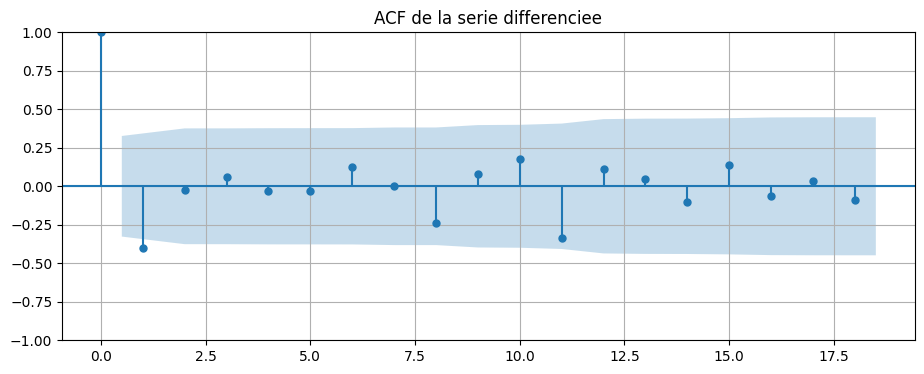

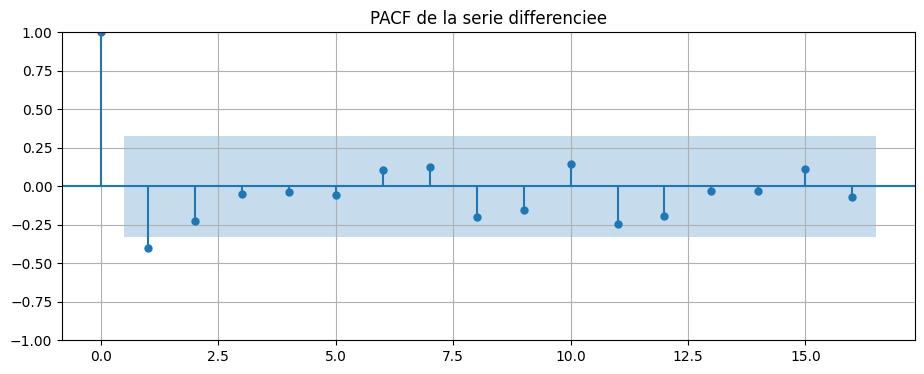

In [8]:
max_acf_lags = min(24, len(ts_stationary)//2)
max_pacf_lags = min(16, max(1, len(ts_stationary)//2 - 1))

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(ts_stationary, lags=max_acf_lags, ax=ax)
ax.set_title("ACF de la série stationnaire retenue")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
plot_pacf(ts_stationary, lags=max_pacf_lags, ax=ax, method="ywm")
ax.set_title("PACF de la série stationnaire retenue")
plt.show()

### Interpretation des parametres

- Si la PACF coupe rapidement apres le lag 1 ou 2, on teste \(p=1\) ou \(p=2\).
- Si l'ACF coupe rapidement apres le lag 1 ou 2, on teste \(q=1\) ou \(q=2\).
- Si un pic existe au lag 12, on teste un modele SARIMA avec saisonnalite annuelle \(s=12\).

C'est pour cela que le lab teste une grille raisonnable de modeles ARIMA et SARIMA.

## 7. Train-test temporel

On garde les derniers mois comme periode de test. Contrairement a une regression classique, on ne melange jamais aleatoirement une serie temporelle : l'ordre temporel doit etre respecte.

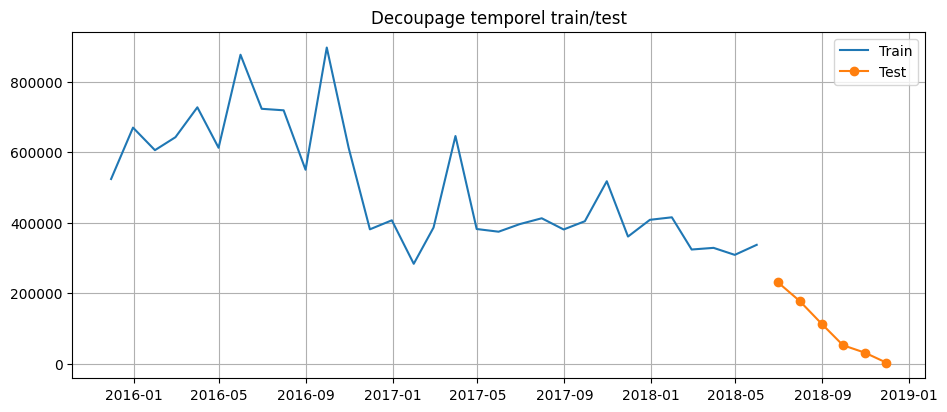

In [9]:
H_TEST = min(6, max(3, len(ts)//5))
train = ts.iloc[:-H_TEST]
test = ts.iloc[-H_TEST:]

plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test", marker="o")
plt.title("Decoupage temporel train/test")
plt.legend()
plt.show()

## 8. Test de modeles ARIMA et SARIMA

### Pourquoi ARIMA ?
ARIMA est adapte aux series non stationnaires apres differenciation. Il combine :

- AR(p) : dependance au passe ;
- I(d) : differenciation ;
- MA(q) : correction par les erreurs passees.

### Pourquoi SARIMA ?
SARIMA ajoute une structure saisonniere :

\[
SARIMA(p,d,q)(P,D,Q)_s
\]

Ici, \(s=12\) car les donnees sont mensuelles.

In [10]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100
    return round(mae, 2), round(rmse, 2), round(mape, 2)

results = []
best = None

# Grille ARIMA courte et interpretable
for p in range(0, 3):
    for d in [0, 1]:
        for q in range(0, 3):
            if p == d == q == 0:
                continue
            try:
                fit = ARIMA(train, order=(p, d, q)).fit()
                pred = fit.forecast(steps=len(test))
                mae, rmse, mape = compute_metrics(test, pred)
                row = {
                    "model": "ARIMA",
                    "order": (p, d, q),
                    "seasonal_order": None,
                    "AIC": round(fit.aic, 2),
                    "MAE": mae,
                    "RMSE": rmse,
                    "MAPE": mape,
                    "fit": fit,
                    "pred": pred,
                }
                results.append(row)
                if best is None or row["RMSE"] < best["RMSE"]:
                    best = row
            except Exception as e:
                pass

# Grille SARIMA courte : d=1 et D=1, saisonnalite annuelle s=12
for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    fit = SARIMAX(
                        train,
                        order=(p, 1, q),
                        seasonal_order=(P, 1, Q, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)
                    pred = fit.forecast(steps=len(test))
                    mae, rmse, mape = compute_metrics(test, pred)
                    row = {
                        "model": "SARIMA",
                        "order": (p, 1, q),
                        "seasonal_order": (P, 1, Q, 12),
                        "AIC": round(fit.aic, 2),
                        "MAE": mae,
                        "RMSE": rmse,
                        "MAPE": mape,
                        "fit": fit,
                        "pred": pred,
                    }
                    results.append(row)
                    if row["RMSE"] < best["RMSE"]:
                        best = row
                except Exception as e:
                    pass

scores = pd.DataFrame([{k:v for k,v in r.items() if k not in ["fit", "pred"]} for r in results])
scores = scores.sort_values("RMSE").reset_index(drop=True)
scores.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,order,seasonal_order,AIC,MAE,RMSE,MAPE
0,SARIMA,"(0, 1, 0)","(1, 1, 0, 12)",161.86,95160.93,140564.39,452.12
1,SARIMA,"(0, 1, 2)","(1, 1, 0, 12)",167.32,106982.34,156112.46,299.05
2,SARIMA,"(0, 1, 1)","(1, 1, 0, 12)",165.19,143923.72,178751.94,630.27
3,SARIMA,"(1, 1, 0)","(1, 1, 0, 12)",138.31,136712.75,179284.44,435.24
4,SARIMA,"(1, 1, 1)","(1, 1, 0, 12)",140.14,134931.74,179546.16,384.08
5,SARIMA,"(2, 1, 0)","(1, 1, 0, 12)",114.02,131565.30,180024.19,288.54
6,SARIMA,"(1, 1, 2)","(1, 1, 0, 12)",141.23,159945.87,190639.89,721.40
7,SARIMA,"(2, 1, 2)","(1, 1, 0, 12)",116.68,172623.29,199784.25,713.46
8,SARIMA,"(2, 1, 1)","(1, 1, 0, 12)",115.09,165909.88,224757.02,2941.54
9,SARIMA,"(2, 1, 0)","(0, 1, 0, 12)",438.24,202298.47,230804.22,1768.46


Test du modele Prophet

Pourquoi Prophet?

Prophet gère automatiquement la tendance et la saisonnalité sans imposer de stationnarité — contrairement à ARIMA qui exige différenciation, tests ADF/KPSS et choix manuel des ordres p, d, q.

In [20]:
from prophet import Prophet # Import Prophet

# ── Préparation des données pour Prophet ─────────────────────────────────────
# Prophet exige deux colonnes : 'ds' (dates) et 'y' (valeurs)
# 'train' and 'test' are pandas Series with DatetimeIndex and values (TARGET)
train_prophet = train.reset_index().rename(columns={train.index.name: 'ds', train.name: 'y'})
test_prophet  = test.reset_index().rename(columns={test.index.name: 'ds', test.name: 'y'})

# ── Ajustement du modèle Prophet ─────────────────────────────────────────────
print("🔧 Ajustement Prophet ...")
prophet_model = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(train_prophet)

# ── Prévision sur la période test ────────────────────────────────────────────
future = prophet_model.make_future_dataframe(periods=len(test), freq='MS')
forecast_prophet = prophet_model.predict(future)

# Extraire les prévisions test
yhat_test = forecast_prophet.tail(len(test))['yhat'].values
y_true = test.values # Corrected from y_test.values

# Use the existing compute_metrics function for consistency
mae_p, rmse_p, mape_p = compute_metrics(y_true, yhat_test)

res_prophet = {
    "model": "Prophet",
    "order": None, # Prophet doesn't have p,d,q orders
    "seasonal_order": None, # Prophet has its own seasonality parameters
    "AIC": None, # Prophet doesn't directly provide AIC like statsmodels
    "MAE": mae_p,
    "RMSE": rmse_p,
    "MAPE": mape_p,
    "fit": prophet_model, # Store the fitted model object
    "pred": pd.Series(yhat_test, index=test.index), # Store predictions as a Series with proper index
}
results.append(res_prophet)

# Update 'best' if Prophet is better
if best is None or res_prophet["RMSE"] < best["RMSE"]:
    best = res_prophet

print(f"   MAE={mae_p:.2f}  RMSE={rmse_p:.2f}  MAPE={mape_p:.1f}%")
print("\n✅ Modèle Prophet ajusté.")

🔧 Ajustement Prophet ...


INFO:prophet:n_changepoints greater than number of observations. Using 23.


   MAE=297319.29  RMSE=423714.69  MAPE=1075.0%

✅ Modèle Prophet ajusté.


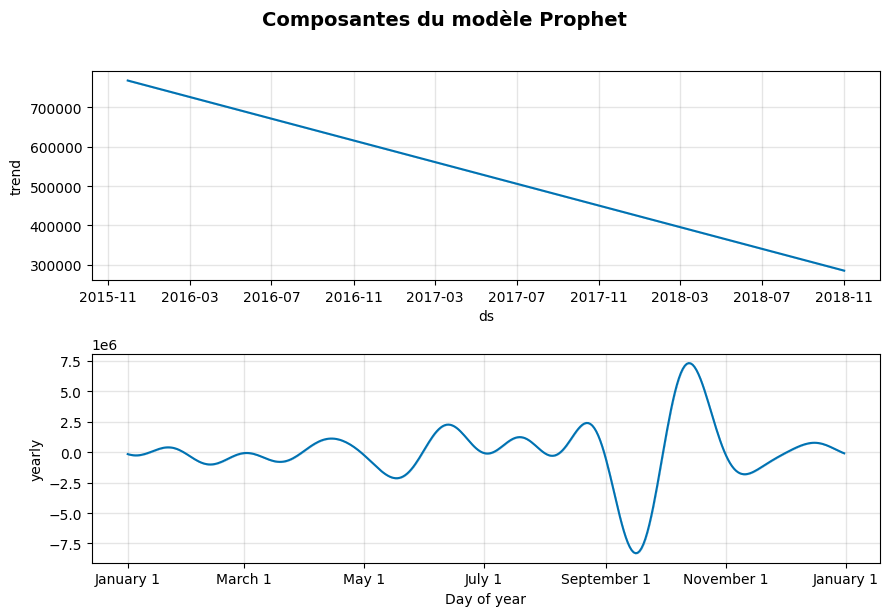

📝 Prophet décompose la série en tendance + saisonnalité annuelle


In [21]:
fig = prophet_model.plot_components(forecast_prophet)
fig.suptitle('Composantes du modèle Prophet', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("📝 Prophet décompose la série en tendance + saisonnalité annuelle")

### Interpretation des scores

- **MAE** : erreur moyenne absolue, facile a interpreter dans l'unite de la serie.
- **RMSE** : penalise plus fortement les grosses erreurs.
- **MAPE** : erreur relative en pourcentage, sensible lorsque les valeurs reelles sont proches de zero.
- **AIC** : critere statistique penalise par la complexite ; utile pour comparer des modeles ajustes sur la meme serie.

Le modele retenu est celui qui offre le meilleur compromis entre erreur de prediction, simplicite et diagnostic des residus.

## 9. Validation du meilleur modele

In [24]:
if best["model"] == "ARIMA":
    final_model = ARIMA(ts, order=best["order"]).fit()
elif best["model"] == "SARIMA":
    final_model = SARIMAX(ts, order=best["order"],
                          seasonal_order=best["seasonal_order"],
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False)
elif best["model"] == "Prophet":
    # Re-entraîner Prophet sur toute la série
    all_data = ts.reset_index().rename(columns={ts.index.name: 'ds', ts.name: 'y'})
    final_model = Prophet(seasonality_mode='additive', yearly_seasonality=True,
                          weekly_seasonality=False, daily_seasonality=False)
    final_model.fit(all_data)

Meilleur modele : SARIMA
Ordre : (0, 1, 0)
Ordre saisonnier : (1, 1, 0, 12)
MAE/RMSE/MAPE : 95160.93 140564.39 452.12


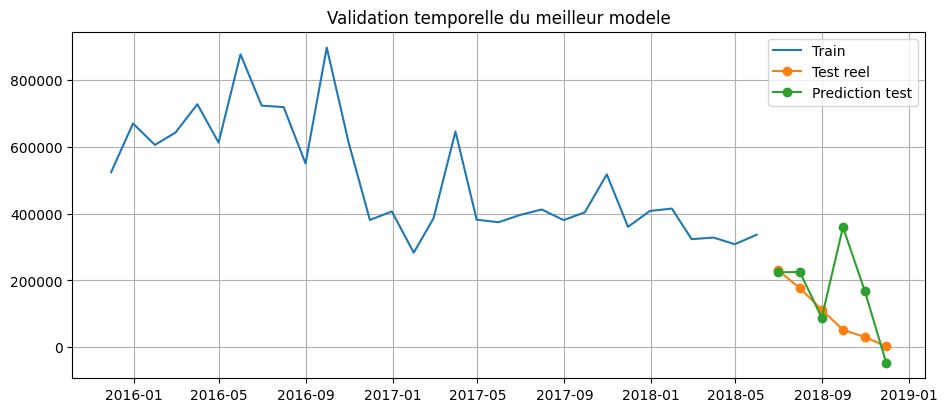

In [25]:
print("Meilleur modele :", best["model"])
print("Ordre :", best["order"])
print("Ordre saisonnier :", best["seasonal_order"])
print("MAE/RMSE/MAPE :", best["MAE"], best["RMSE"], best["MAPE"])

plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test reel", marker="o")
plt.plot(test.index, best["pred"].values, label="Prediction test", marker="o")
plt.title("Validation temporelle du meilleur modele")
plt.legend()
plt.show()

## 10. Ajustement final et prevision

On re-entraine le meilleur modele sur toute la serie disponible, puis on prevoit les 12 prochains mois.

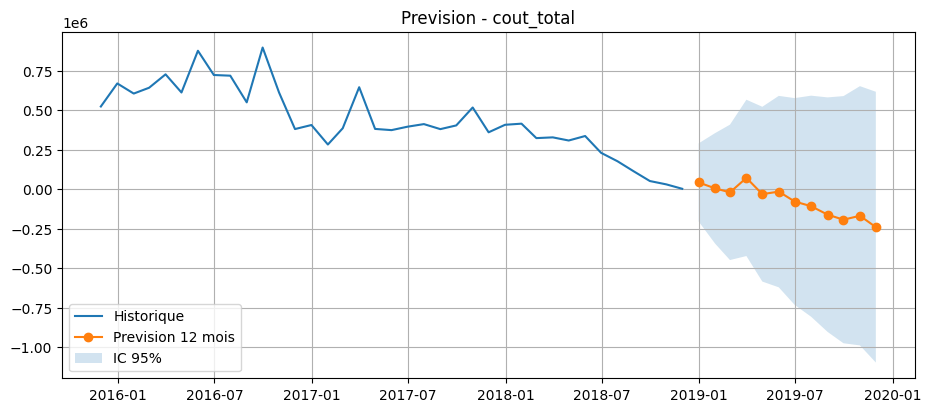

,forecast
2018-12-31,43031.019828
2019-01-31,5690.245352
2019-02-28,-19529.931247
2019-03-31,72004.045100
2019-04-30,-30967.728115
2019-05-31,-14804.311912
2019-06-30,-77501.861858
2019-07-31,-107150.543549
2019-08-31,-160511.972166
2019-09-30,-192441.472614


In [12]:
if best["model"] == "ARIMA":
    final_model = ARIMA(ts, order=best["order"]).fit()
else:
    final_model = SARIMAX(
        ts,
        order=best["order"],
        seasonal_order=best["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

forecast_obj = final_model.get_forecast(steps=12)
forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure()
plt.plot(ts.index, ts.values, label="Historique")
plt.plot(forecast.index, forecast.values, label="Prevision 12 mois", marker="o")
try:
    plt.fill_between(forecast.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.2, label="IC 95%")
except Exception:
    pass
plt.title(f"Prevision - {TARGET}")
plt.legend()
plt.show()

forecast.to_frame("forecast")

### Interpretation actuarielle

La prevision donne une estimation du cout futur des sinistres. Elle peut etre utilisee pour :

- anticiper le besoin de provisions ;
- ajuster la prime pure attendue ;
- comparer le cout futur attendu aux primes encaissees ;
- detecter une degradation potentielle de la sinistralite.

Attention : avec un historique court, les intervalles de confiance peuvent etre larges. Le resultat doit donc etre utilise comme aide a la decision, pas comme valeur contractuelle.

## 11. Analyse residuelle

Un bon modele doit produire des residus proches d'un bruit blanc :

- moyenne proche de zero ;
- absence d'autocorrelation significative ;
- pas de structure temporelle visible.

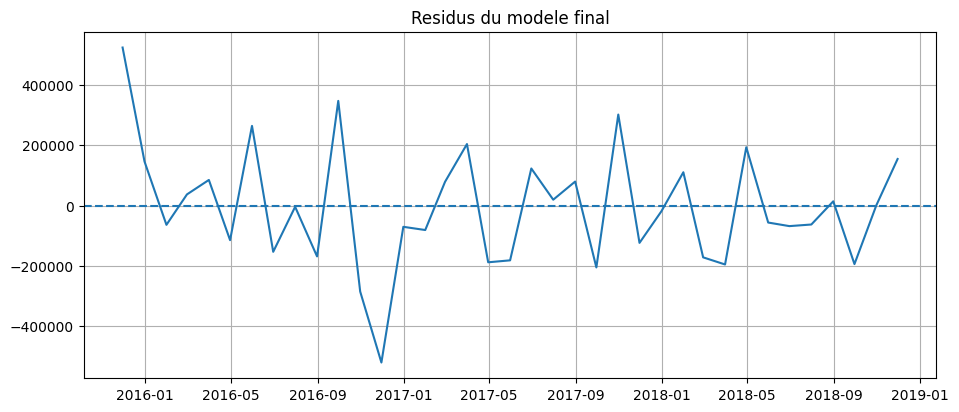

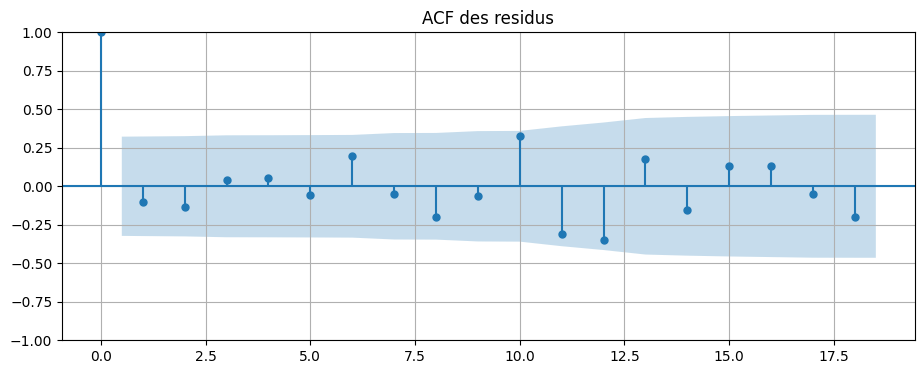

,lb_stat,lb_pvalue
10,11.384092,0.328387


In [13]:
residuals = final_model.resid.dropna()

plt.figure()
plt.plot(residuals.index, residuals.values)
plt.axhline(0, linestyle="--")
plt.title("Residus du modele final")
plt.show()

fig, ax = plt.subplots(figsize=(11,4))
plot_acf(residuals, lags=min(20, len(residuals)//2), ax=ax)
ax.set_title("ACF des residus")
plt.show()

lb = acorr_ljungbox(residuals, lags=[min(10, max(1, len(residuals)//2))], return_df=True)
lb

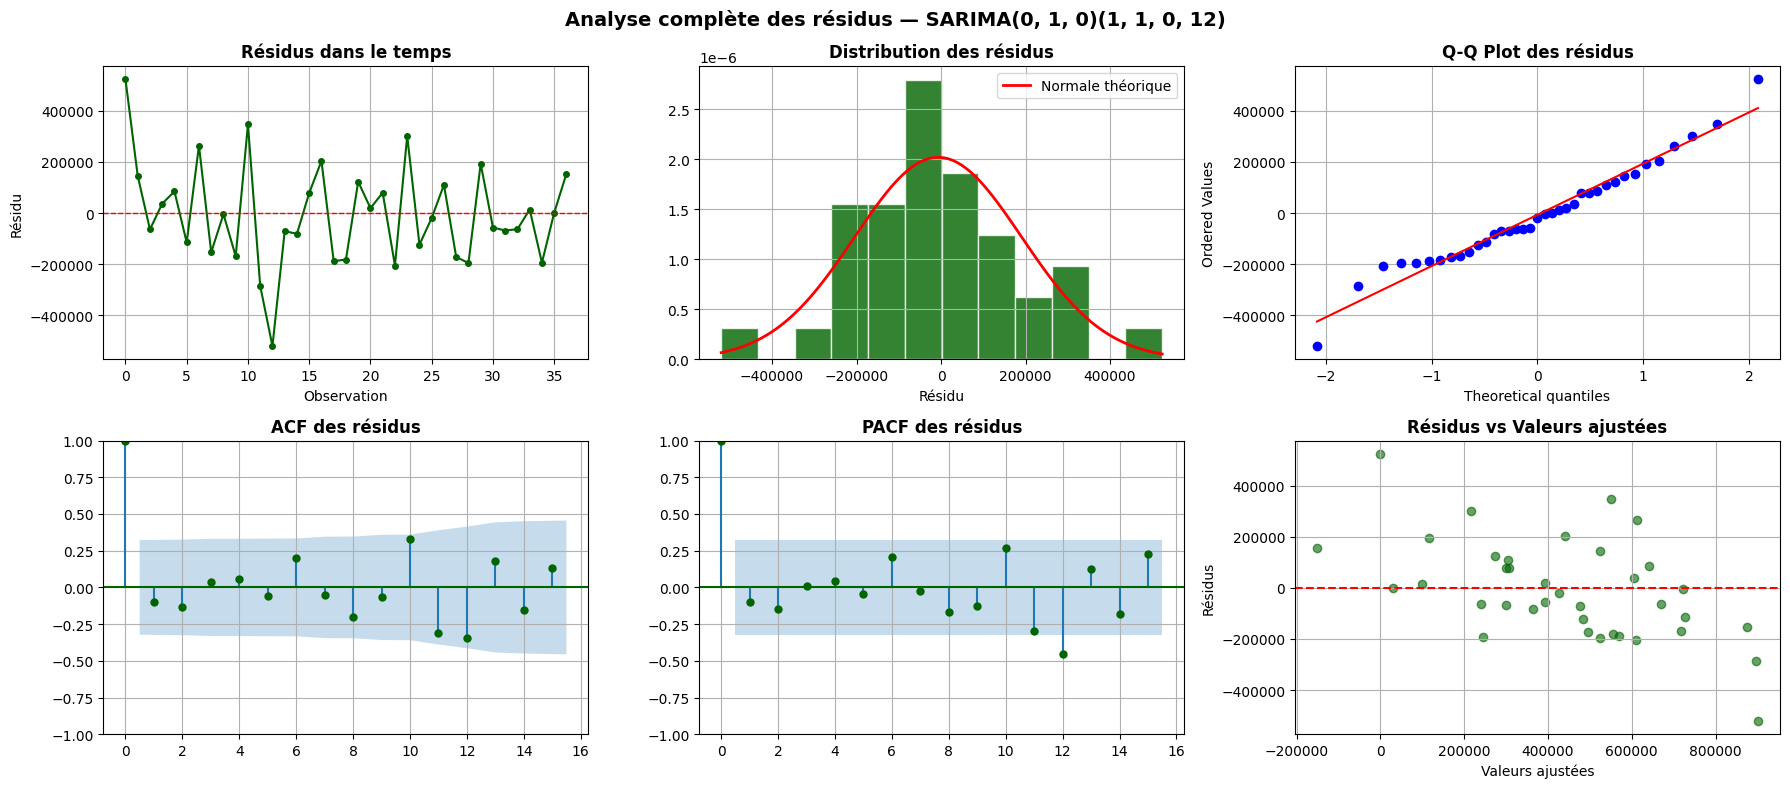

In [16]:
import scipy.stats as stats


### Interpretation du test de Ljung-Box

- p-value > 0.05 : on ne detecte pas d'autocorrelation residuelle significative ; le modele est acceptable.
- p-value <= 0.05 : les residus contiennent encore de l'information ; il faut revoir les ordres ARIMA/SARIMA ou ajouter des variables explicatives.

In [22]:
# ── Tests formels sur les résidus ────────────────────────────────────────────
print("="*55)
print("  Tests formels sur les résidus")
print("="*55)

# Test de Ljung-Box (autocorrélation)
lb_res = acorr_ljungbox(residuals.dropna(), lags=[5, 10], return_df=True)
print("\n  Test de Ljung-Box (H₀ : pas d'autocorrélation)")
print(f"  {'Lag':<6} {'Stat':<12} {'p-value':<12} {'Conclusion'}")
for lag, row in lb_res.iterrows():
    conc = "✅ Pas d'autocorr." if row['lb_pvalue'] > 0.05 else "❌ Autocorrélation"
    print(f"  {lag:<6} {row['lb_stat']:<12.4f} {row['lb_pvalue']:<12.4f} {conc}")

  Tests formels sur les résidus

  Test de Ljung-Box (H₀ : pas d'autocorrélation)
  Lag    Stat         p-value      Conclusion
  5      1.4762       0.9158       ✅ Pas d'autocorr.
  10     11.3841      0.3284       ✅ Pas d'autocorr.


## 12. Conclusion du lab

Ce lab montre la demarche complete d'une analyse temporelle :

1. construction d'une serie mensuelle ;
2. analyse visuelle et decomposition ;
3. test de stationnarite ;
4. differenciation ;
5. ACF/PACF pour guider les parametres ;
6. comparaison ARIMA/SARIMA ;
7. validation temporelle ;
8. diagnostic des residus ;
9. prevision et interpretation actuarielle.

Dans un contexte assurance, le modele choisi peut etre utilise pour anticiper la charge de sinistres, piloter la tarification et surveiller la rentabilite du portefeuille.

## 13. Export des resultats pour le rapport

Cette cellule sauvegarde les figures et les scores dans un dossier `figures_temporal/`.

In [14]:
OUT = Path("figures_temporal")
OUT.mkdir(exist_ok=True)

# Figures principales
plt.figure(figsize=(11,4.5))
plt.plot(ts.index, ts.values, marker="o")
plt.title(f"Serie temporelle mensuelle - {TARGET}")
plt.savefig(OUT / "serie_historique.png", dpi=180, bbox_inches="tight")
plt.close()

if len(ts.dropna()) >= 24:
    decomp = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")
    fig = decomp.plot(); fig.set_size_inches(11,7)
    plt.savefig(OUT / "decomposition.png", dpi=180, bbox_inches="tight")
    plt.close()

fig, ax = plt.subplots(figsize=(11,4))
plot_acf(ts_diff, lags=max_acf_lags, ax=ax)
plt.savefig(OUT / "acf.png", dpi=180, bbox_inches="tight")
plt.close()

fig, ax = plt.subplots(figsize=(11,4))
plot_pacf(ts_diff, lags=max_pacf_lags, ax=ax, method="ywm")
plt.savefig(OUT / "pacf.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(11,4.5))
plt.plot(test.index, test.values, label="Test reel", marker="o")
plt.plot(test.index, best["pred"].values, label="Prediction", marker="o")
plt.title("Validation du meilleur modele")
plt.legend()
plt.savefig(OUT / "validation.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(11,4.5))
plt.plot(ts.index, ts.values, label="Historique")
plt.plot(forecast.index, forecast.values, label="Prevision", marker="o")
try:
    plt.fill_between(forecast.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=.2, label="IC 95%")
except Exception:
    pass
plt.title("Prevision 12 mois")
plt.legend()
plt.savefig(OUT / "forecast.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(11,4))
plt.plot(residuals.index, residuals.values)
plt.axhline(0, linestyle="--")
plt.title("Residus")
plt.savefig(OUT / "residus.png", dpi=180, bbox_inches="tight")
plt.close()

scores.to_csv(OUT / "scores_modeles.csv", index=False)
forecast.to_frame("forecast").to_csv(OUT / "prevision_12_mois.csv")

print("Exports crees dans", OUT.resolve())

Exports crees dans /content/figures_temporal
